In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [31]:
dorota_outputs = pd.read_csv(r"z:\Bel\Dorota_Vascumap\combined_analysis_metrics_dorota.csv")
dorota_outputs["author"] = "dorota"
farid_outputs = pd.read_csv(r"z:\Bel\Farid_bel\New_Experiment_Outputs_output_data\farid_combined_analysis_metrics.csv")
farid_outputs["author"] = "farid1"
farid_outputs_2 = pd.read_csv(r"z:\Bel\Farid_bel\Old_Experiment_Outputs_output_data\farid_combined_analysis_metrics.csv")
farid_outputs_2["author"] = "farid2"

In [32]:
all_outputs = pd.concat([dorota_outputs, farid_outputs, farid_outputs_2])

In [33]:
all_outputs.drop(["image_name", "image_index", "chip_volume_um3", "convex_hull_volume_um3", "vessel_volume_um3", "total_vessel_length_um",'source_folder', 'Unnamed: 0', 'experiment', "p90_minus_p10_internal_pore_max_inscribed_radius_um", "median_internal_pore_max_inscribed_radius_um", "internal_pore_area_fraction_in_filled_vascular_area", "total_internal_pore_count" ], axis=1, inplace=True)

In [34]:
all_outputs.columns

Index(['source_file', 'vessel_volume_fraction',
       'vessel_length_per_chip_volume_um_inverse2',
       'sprouts_per_vessel_length_um_inverse',
       'junctions_per_vessel_length_um_inverse', 'skeleton_fractal_dimension',
       'skeleton_lacunarity', 'median_sprout_and_branch_orientation_deg',
       'p90_minus_p10_sprout_and_branch_orientation_deg',
       'median_sprout_and_branch_median_cs_area_um2',
       'p90_minus_p10_sprout_and_branch_median_cs_area_um2',
       'median_junction_dist_nearest_junction_um',
       'p90_minus_p10_junction_dist_nearest_junction_um',
       'median_sprout_dist_nearest_endpoint_um',
       'p90_minus_p10_sprout_dist_nearest_endpoint_um',
       'average_vessel_volume_um3', 'median_internal_pore_area_um2',
       'p90_minus_p10_internal_pore_area_um2',
       'sprouts_per_chip_volume_um_inverse3',
       'junctions_per_chip_volume_um_inverse3',
       'total_internal_pore_density_per_vessel_volume_um_inverse3', 'author'],
      dtype='object')

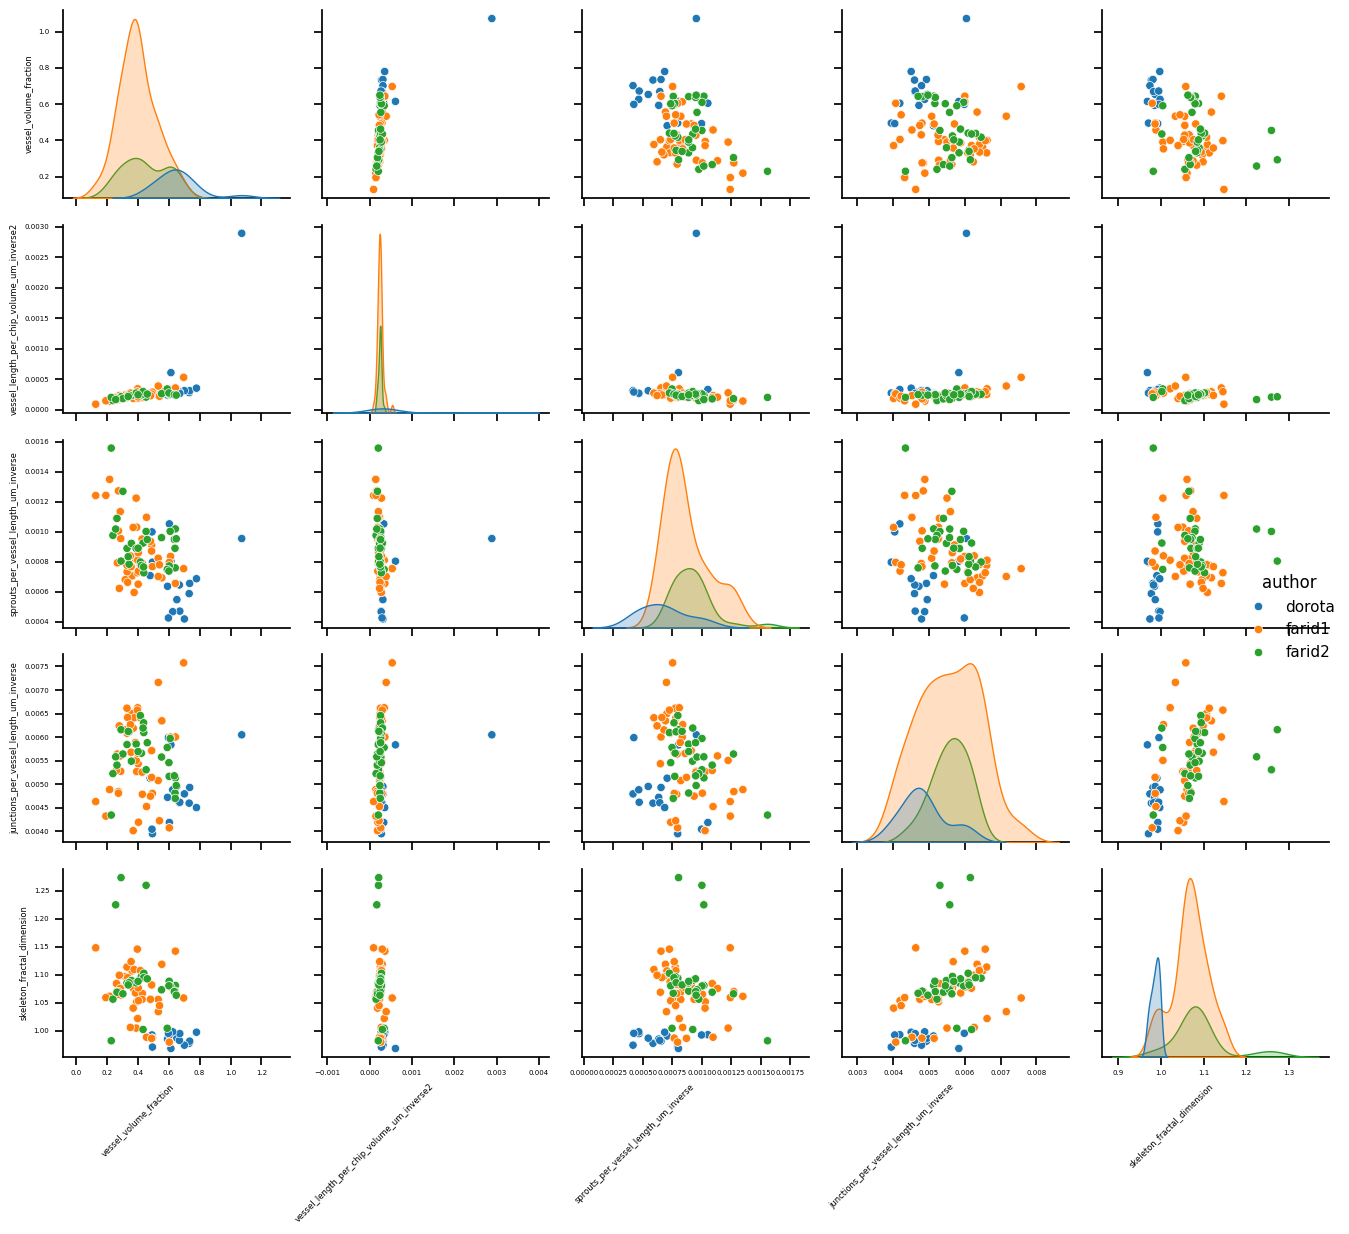

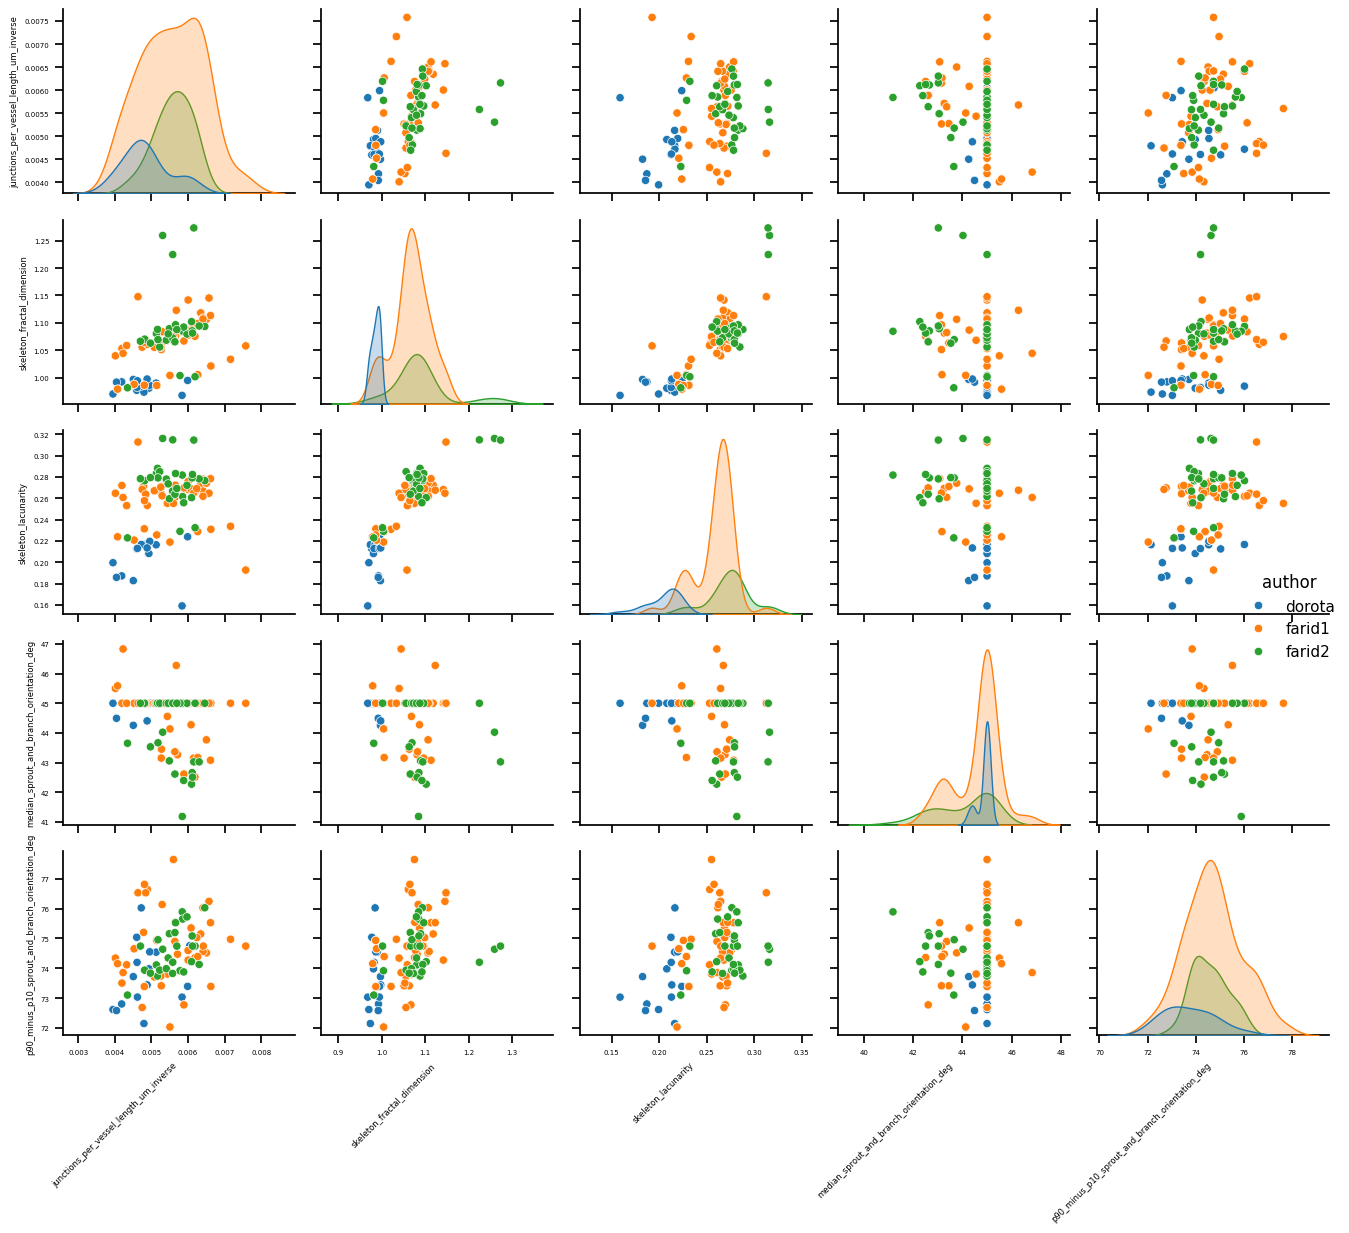

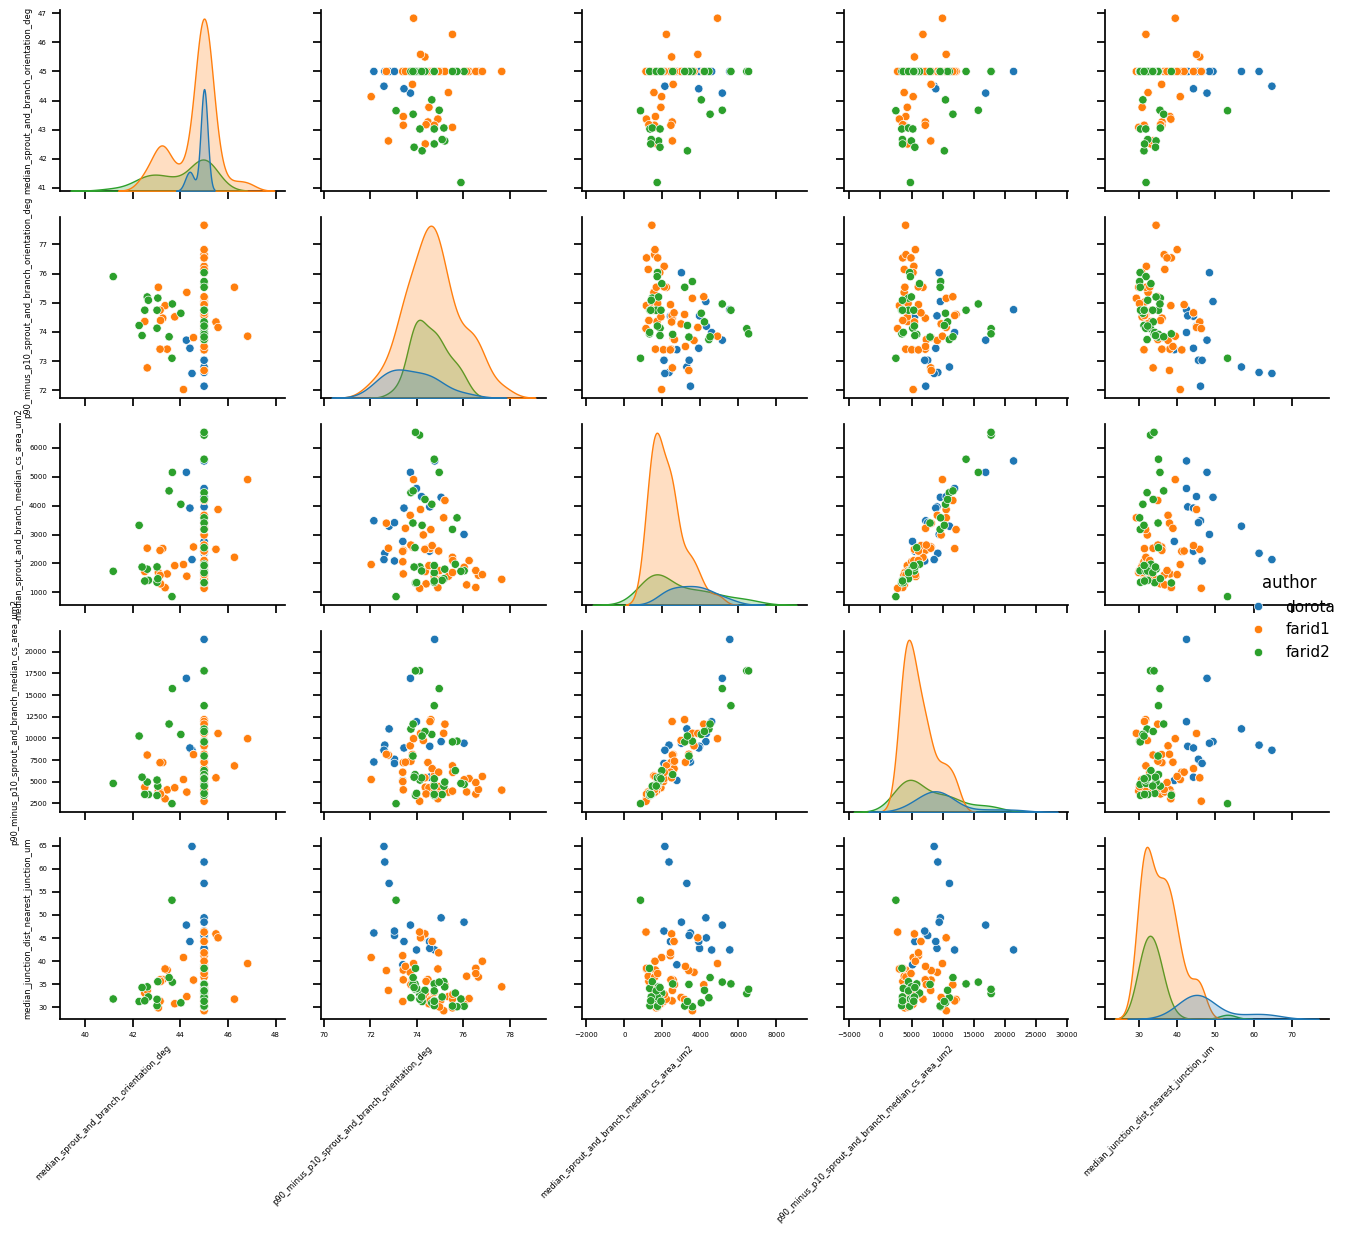

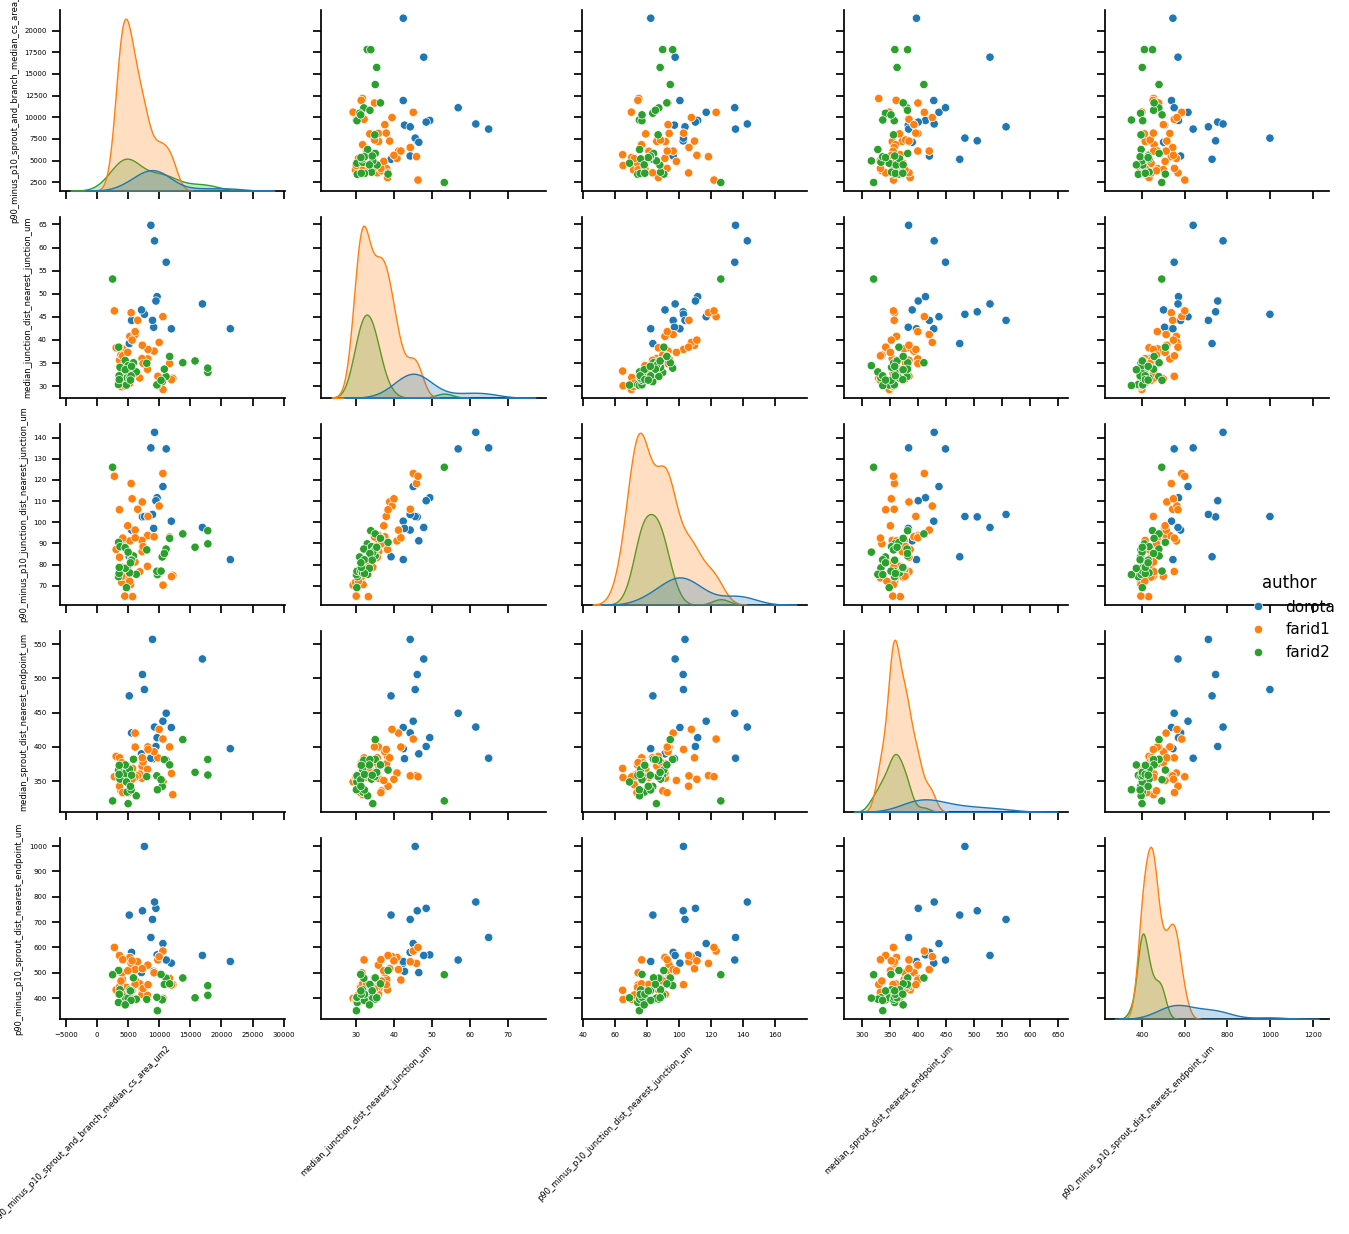

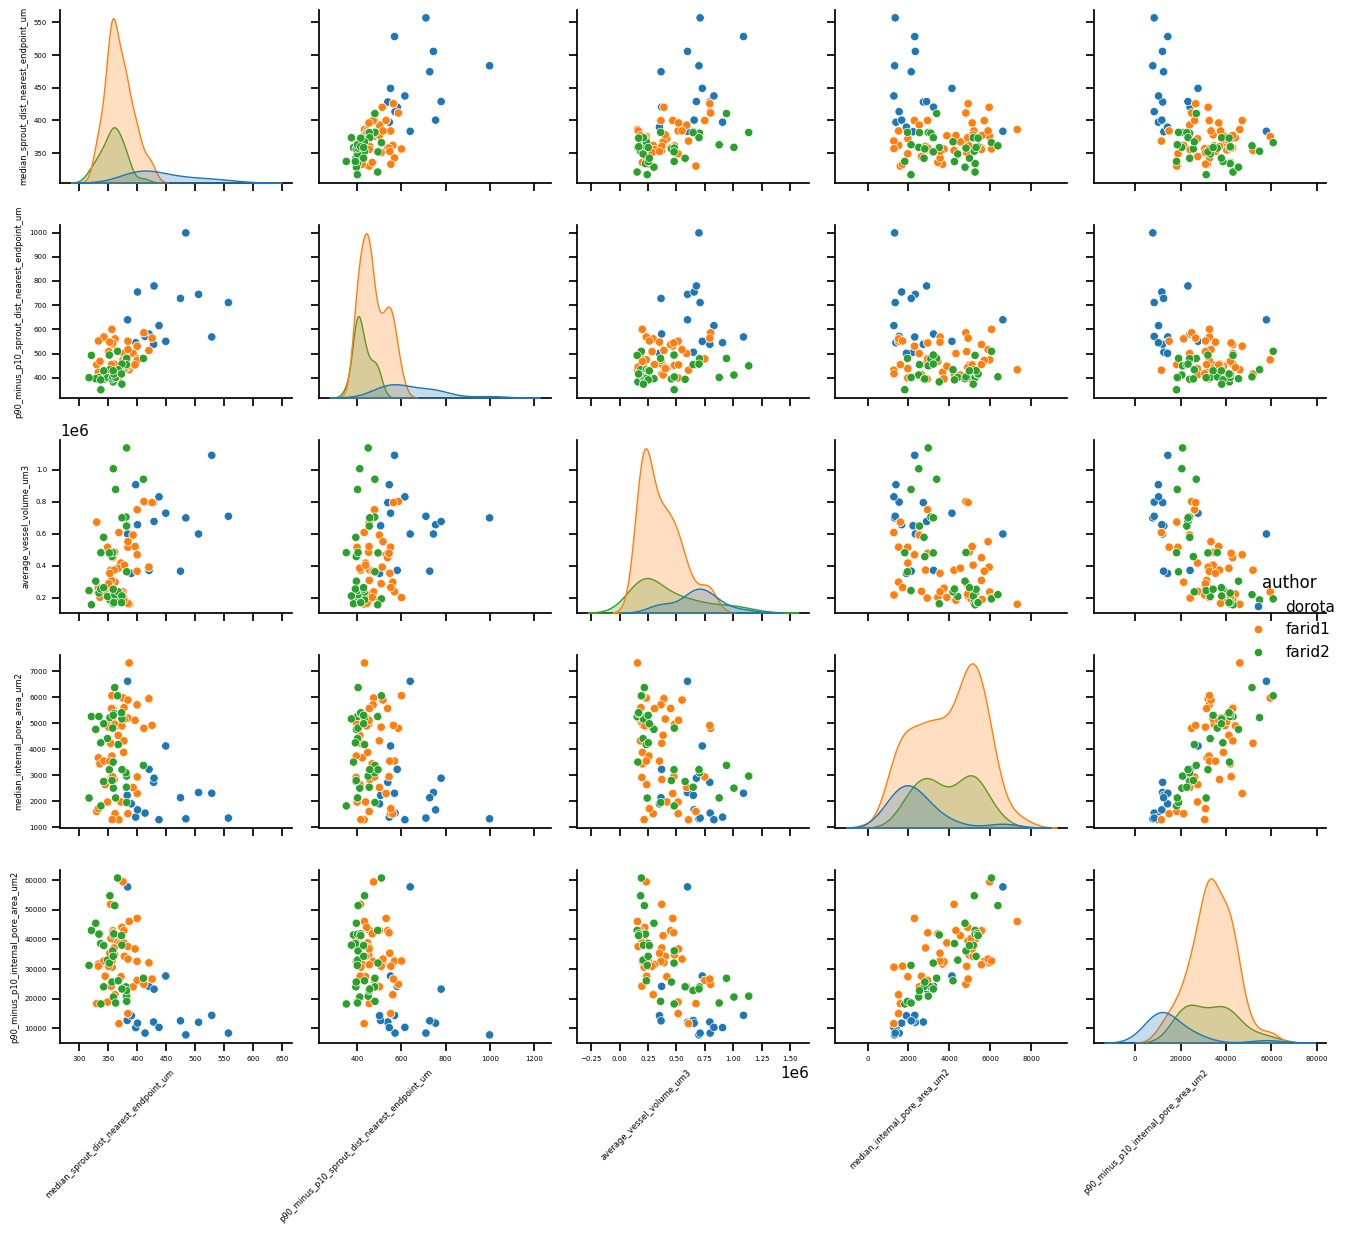

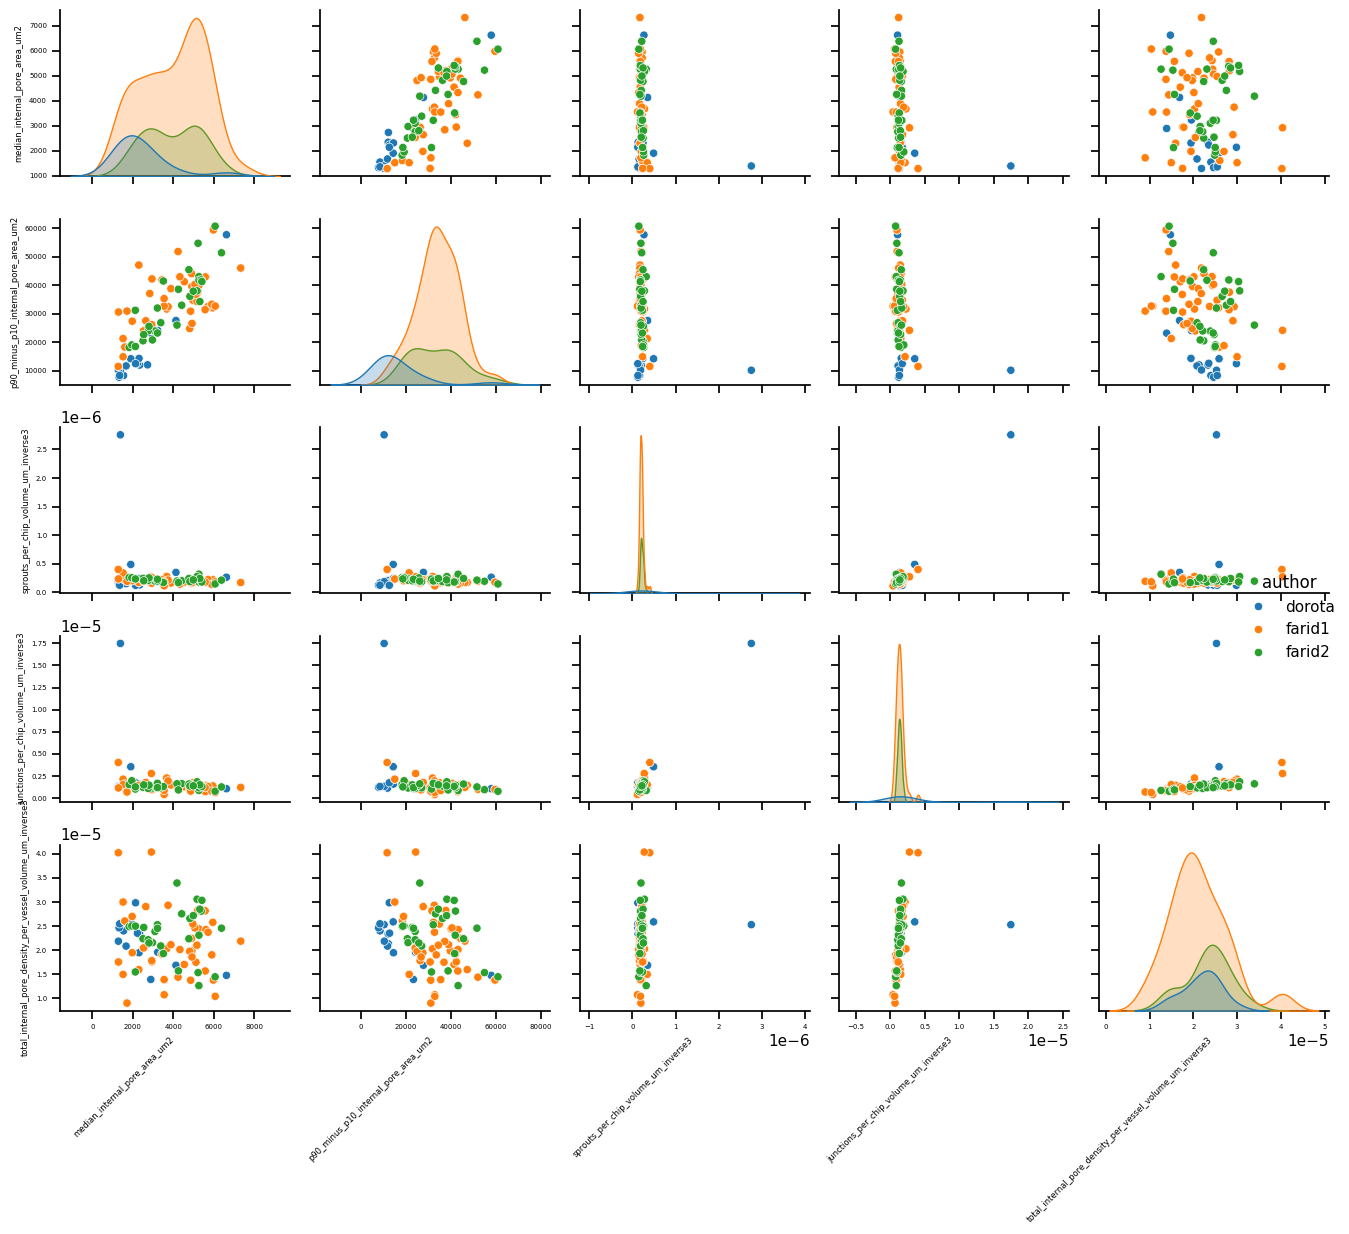

ValueError: 2

In [35]:
numeric_cols = all_outputs.select_dtypes(include="number").reset_index(drop=True)
numeric_cols["author"] = all_outputs["author"].reset_index(drop=True)
for i in range(0, numeric_cols.shape[1] - 1, 3):
    cols = list(numeric_cols.columns[i: i+5]) + ["author"]
    p = sns.pairplot(numeric_cols[cols], hue="author")
    for ax in p.axes.flat:
        ax.tick_params(labelsize=5)
        if ax.get_xlabel():
            ax.set_xlabel(ax.get_xlabel(), fontsize=6, rotation=45, ha="right")
        if ax.get_ylabel():
            ax.set_ylabel(ax.get_ylabel(), fontsize=6)
    plt.tight_layout()
    plt.show()

In [36]:
numeric_cols.columns

Index(['vessel_volume_fraction', 'vessel_length_per_chip_volume_um_inverse2',
       'sprouts_per_vessel_length_um_inverse',
       'junctions_per_vessel_length_um_inverse', 'skeleton_fractal_dimension',
       'skeleton_lacunarity', 'median_sprout_and_branch_orientation_deg',
       'p90_minus_p10_sprout_and_branch_orientation_deg',
       'median_sprout_and_branch_median_cs_area_um2',
       'p90_minus_p10_sprout_and_branch_median_cs_area_um2',
       'median_junction_dist_nearest_junction_um',
       'p90_minus_p10_junction_dist_nearest_junction_um',
       'median_sprout_dist_nearest_endpoint_um',
       'p90_minus_p10_sprout_dist_nearest_endpoint_um',
       'average_vessel_volume_um3', 'median_internal_pore_area_um2',
       'p90_minus_p10_internal_pore_area_um2',
       'sprouts_per_chip_volume_um_inverse3',
       'junctions_per_chip_volume_um_inverse3',
       'total_internal_pore_density_per_vessel_volume_um_inverse3', 'author'],
      dtype='object')

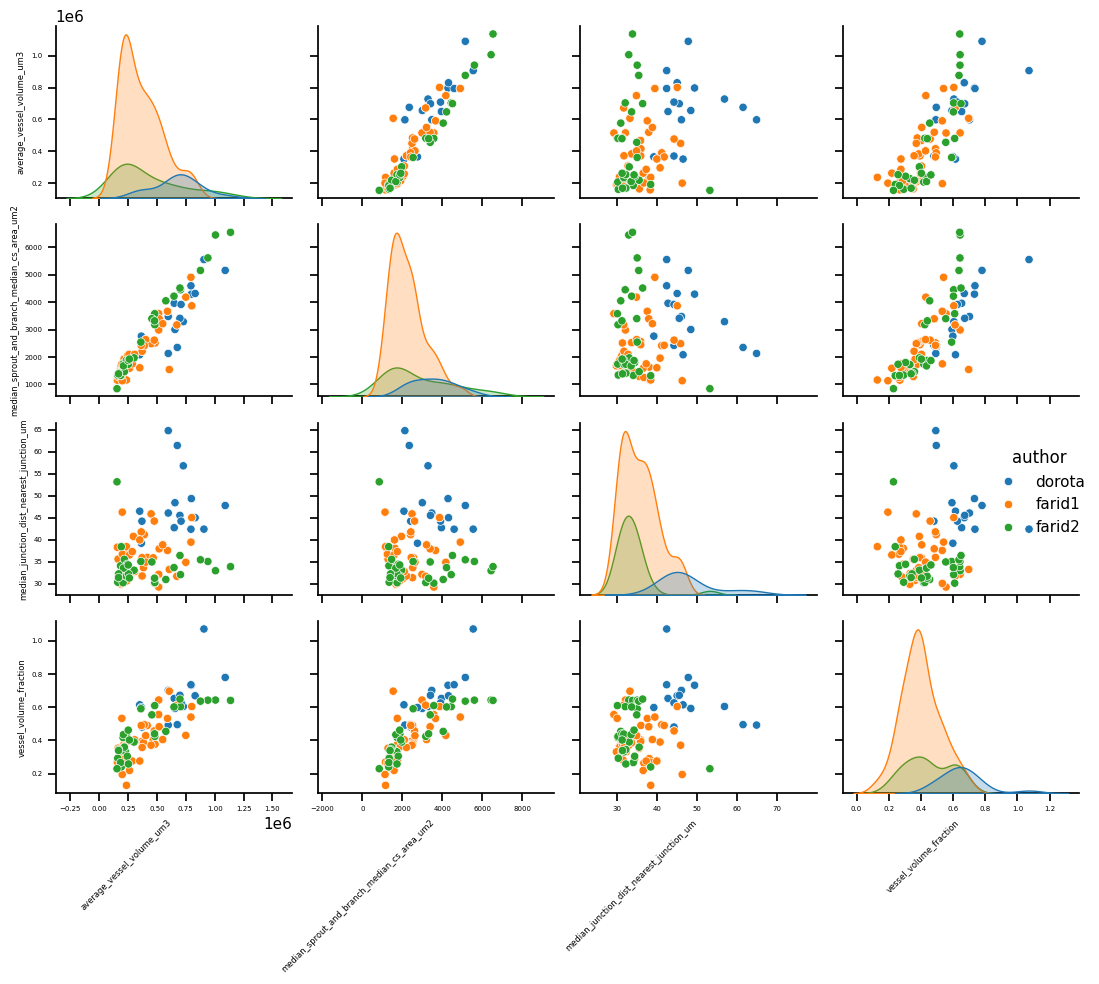

In [38]:
columns_of_interest = numeric_cols[["average_vessel_volume_um3", "median_sprout_and_branch_median_cs_area_um2", "median_junction_dist_nearest_junction_um", "vessel_volume_fraction", "author"]]

p = sns.pairplot(columns_of_interest, hue="author")
for ax in p.axes.flat:
    ax.tick_params(labelsize=5)
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), fontsize=6, rotation=45, ha="right")
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), fontsize=6)
plt.tight_layout()
plt.show()


In [5]:
initial_speed = pd.read_csv(r"z:\Bel\Vascumap_Speed_Test\Device_Segmentation\Baseline\batch_timings.csv")
final_speed = pd.read_csv(r"z:\Bel\Vascumap_Speed_Test\Device_Segmentation\Just_Hough\batch_timings.csv")

In [6]:
initial_speed.t_job_wall_s.mean(), final_speed.t_job_wall_s.mean()

(np.float64(53.65652173913043), np.float64(55.72608695652173))

In [4]:
initial_speed = pd.read_csv(r"z:\Bel\Vascumap_Speed_Test\z_Resampling\baseline\batch_timings.csv")
coarse_speed = pd.read_csv(r"z:\Bel\Vascumap_Speed_Test\z_Resampling\coarse_refine\batch_timings.csv")

In [12]:
brenner = pd.read_csv(r"z:\Bel\Vascumap_Speed_Test\z_Resampling\brenner\batch_timings.csv")
brenner

,image_name,source_file,image_index,status,focus_strategy,n_z_planes_kept,z_start,z_stop,t_focus_s,t_device_seg_s,t_preprocess_s,t_inference_s,t_analysis_s,t_pipeline_s,t_job_wall_s
0,20250619_Vascumap_Dev25_11_Daisy10,20250619_Vascumap_Dev25_11_Daisy10.tif,0,OK,brenner,33.0,31.0,64.0,0.89,45.1,64.4,699.5,33.5,804.7,853.1
1,20250619_Vascumap_Dev25_11_WicellWicellECFB10,20250619_Vascumap_Dev25_11_WicellWicellECFB10.tif,0,OK,brenner,33.0,43.0,76.0,0.91,56.0,38.8,460.1,26.1,531.1,590.5
2,Akinola_09102024_day7_hmvec_cs_merged_img0,Akinola_09102024_day7_hmvec_cs_merged.lif,0,OK,brenner,54.0,44.0,98.0,2.20,67.8,162.6,1986.0,140.8,2308.1,2380.7
3,Akinola_09102024_day7_hmvec_cs_merged_img1,Akinola_09102024_day7_hmvec_cs_merged.lif,1,OK,brenner,53.0,52.0,105.0,2.36,69.4,164.9,1991.7,157.3,2335.0,2410.2
4,Akinola_09102024_day7_hmvec_cs_merged_img2,Akinola_09102024_day7_hmvec_cs_merged.lif,2,OK,brenner,61.0,14.0,75.0,2.22,72.2,130.9,1717.6,157.8,2025.4,2103.7
5,Akinola_09102024_day7_hmvec_cs_merged_img3,Akinola_09102024_day7_hmvec_cs_merged.lif,3,OK,brenner,66.0,14.0,80.0,2.99,77.5,130.1,1705.5,184.6,2042.9,2127.3
6,Akinola_09102024_day7_hmvec_cs_merged_img4,Akinola_09102024_day7_hmvec_cs_merged.lif,4,OK,brenner,68.0,67.0,135.0,2.22,69.1,203.6,2220.4,173.4,2621.2,2699.5
7,Akinola_09102024_day7_hmvec_cs_merged_img5,Akinola_09102024_day7_hmvec_cs_merged.lif,5,OK,brenner,56.0,52.0,108.0,2.70,80.4,167.6,1961.1,151.5,2304.1,2391.4
8,Defne_placenta_270325_Gly_Device_6,Defne_placenta_270325_Gly_Device_6.tif,0,OK,brenner,54.0,0.0,54.0,1.57,65.8,136.8,1557.9,125.8,1840.5,1912.5
9,Dorota_merged_stellaris_R1_007.tif,Dorota_merged_stellaris_R1_007.tif,0,FAILED,brenner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
initial_speed.t_job_wall_s.mean(), coarse_speed.t_job_wall_s.mean()

(np.float64(53.65652173913043), np.float64(1432.7875))